In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("C:\\Users\\shash\\Downloads\\ctg-studies.csv")
df

,Study Title,Study URL,Study Status,Study Results,Conditions,Interventions,Age,Phases,Enrollment,Column1,...,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81,Unnamed: 82,Unnamed: 83,Unnamed: 84,0
0,PAVS in Cardiology,https://clinicaltrials.gov/study/NCT04656132,COMPLETED,YES,Cardiovascular Diseases,"BEHAVIORAL: Physical activity assessment, prom...","ADULT, OLDER_ADULT",PHASE1,63,Study Type,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Ticagrelor With Aspirin or Alone in High-Risk ...,https://clinicaltrials.gov/study/NCT02270242,COMPLETED,YES,Cardiovascular Disease|Interventional Cardiology,DRUG: Aspirin|DRUG: Placebo|DRUG: ticagrelor,"ADULT, OLDER_ADULT",PHASE4,9006,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Study to Evaluate the Effects of MEDI6012 on A...,https://clinicaltrials.gov/study/NCT03773172,TERMINATED,YES,Cardiovascular Diseases,DRUG: MEDI6012|DRUG: Placebo,"ADULT, OLDER_ADULT",PHASE2,7,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"Are the ""Cardiac Benefits"" of Empagliflozin In...",https://clinicaltrials.gov/study/NCT03485222,COMPLETED,YES,Cardiovascular Diseases,DRUG: Empagliflozin|DRUG: Placebos,"ADULT, OLDER_ADULT",PHASE4,84,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cardiometabolic Effects of Pecans as a Snack,https://clinicaltrials.gov/study/NCT05071807,COMPLETED,YES,Cardiovascular Diseases,DRUG: Pecans|OTHER: Usual Care,"ADULT, OLDER_ADULT",PHASE2,138,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,Evaluation of the Efficacy and Safety of Saril...,https://clinicaltrials.gov/study/NCT03600818,TERMINATED,YES,Polymyalgia Rheumatica,DRUG: Sarilumab SAR153191 (REGN88)|DRUG: Saril...,"ADULT, OLDER_ADULT",PHASE3,118,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1302,Sildenafil Treatment for Mild TBI,https://clinicaltrials.gov/study/NCT03598140,TERMINATED,YES,"Vascular System Injuries|Concussion, Brain|Pos...",DRUG: Sildenafil Citrate|DRUG: Placebo oral ca...,ADULT,PHASE2,22,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1303,Aspirin for Prevention of Venous Thromboemboli...,https://clinicaltrials.gov/study/NCT04352439,COMPLETED,YES,Venous Thromboembolism|Ovarian Cancer,DRUG: Aspirin,"ADULT, OLDER_ADULT",PHASE4,19,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1304,Study of Axitinib for Reducing Extent of Venou...,https://clinicaltrials.gov/study/NCT03494816,COMPLETED,YES,Renal Cell Carcinoma|Metastatic Renal Cell Car...,DRUG: Axitinib Oral Tablet,"ADULT, OLDER_ADULT",PHASE2,24,INTERVENTIONAL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df = df.dropna(axis=1, how='all')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
print(df.head())

                                         Study Title  \
0                                 PAVS in Cardiology   
1  Ticagrelor With Aspirin or Alone in High-Risk ...   
2  Study to Evaluate the Effects of MEDI6012 on A...   
3  Are the "Cardiac Benefits" of Empagliflozin In...   
4       Cardiometabolic Effects of Pecans as a Snack   

                                      Study URL Study Status Study Results  \
0  https://clinicaltrials.gov/study/NCT04656132    COMPLETED           YES   
1  https://clinicaltrials.gov/study/NCT02270242    COMPLETED           YES   
2  https://clinicaltrials.gov/study/NCT03773172   TERMINATED           YES   
3  https://clinicaltrials.gov/study/NCT03485222    COMPLETED           YES   
4  https://clinicaltrials.gov/study/NCT05071807    COMPLETED           YES   

                                         Conditions  \
0                           Cardiovascular Diseases   
1  Cardiovascular Disease|Interventional Cardiology   
2                           C

In [30]:
df.dtypes

Study Title             object
Study URL               object
Study Status            object
Study Results           object
Conditions              object
Interventions           object
Age                     object
Phases                  object
Enrollment               int64
Column1                 object
Study Design            object
Start Date              object
Completion Date         object
Results First Posted    object
countries               object
Locations               object
dtype: object

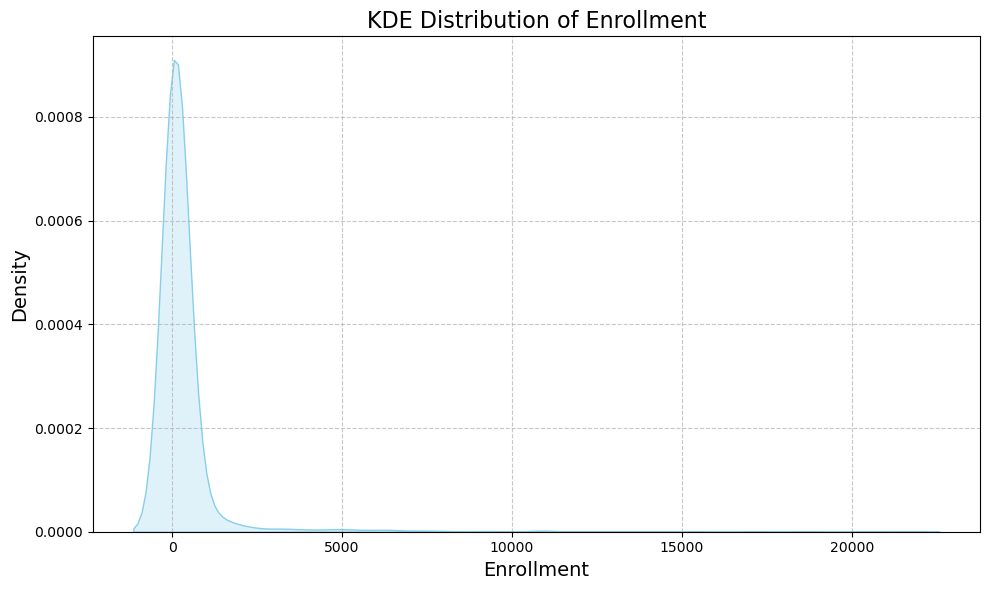

In [31]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='Enrollment', fill=True, color='skyblue', bw_adjust=1)
plt.title('KDE Distribution of Enrollment', fontsize=16)
plt.xlabel('Enrollment', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='Enrollment', ylabel='Count'>

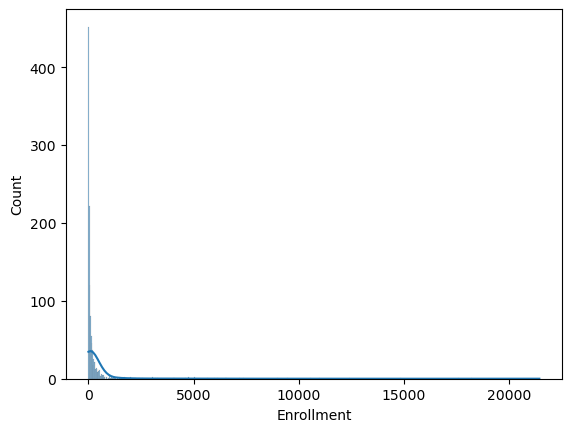

In [32]:
sns.histplot(df['Enrollment'], kde=True)


In [35]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])

skewness = numeric_cols.skew().sort_values(ascending=False)
print(skewness)


Enrollment        8.262627
Enrollment_log    0.527167
dtype: float64


In [36]:
skewed_cols = skewness[skewness > 0.5].index  # You can adjust threshold

for col in skewed_cols:
    df[f'{col}_log'] = np.log1p(df[col])


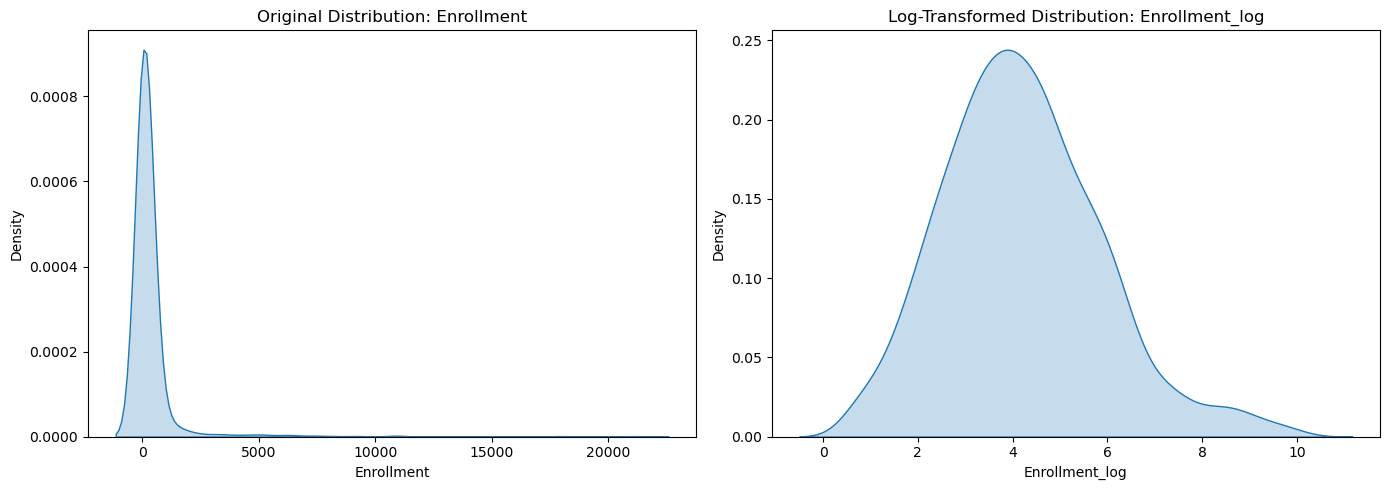

In [37]:
col = 'Enrollment' 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(df[col], fill=True, ax=axes[0])
axes[0].set_title(f'Original Distribution: {col}')

sns.kdeplot(df[f'{col}_log'], fill=True, ax=axes[1])
axes[1].set_title(f'Log-Transformed Distribution: {col}_log')

plt.tight_layout()
plt.show()


# Trial Status Analysis


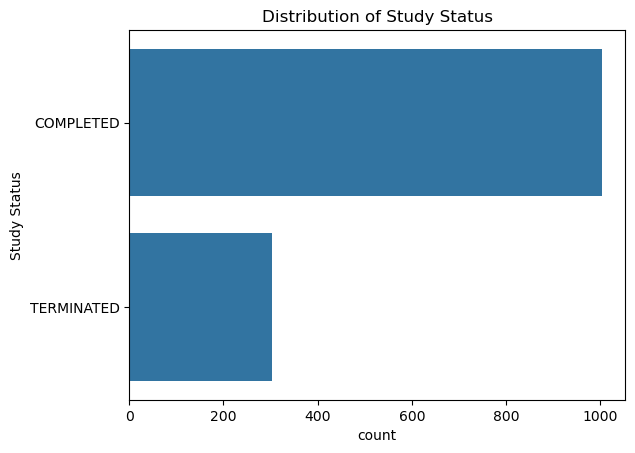

In [38]:
sns.countplot(data=df, y='Study Status')
plt.title("Distribution of Study Status")
plt.show()


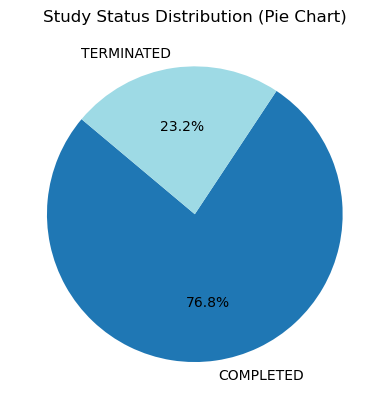

In [39]:
df['Study Status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colormap='tab20')
plt.title("Study Status Distribution (Pie Chart)")
plt.ylabel('')
plt.show()


 # Study Phases Overview

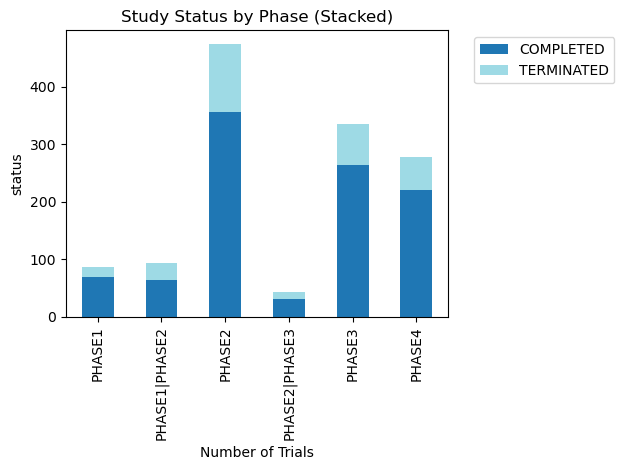

In [40]:
pd.crosstab(df['Phases'], df['Study Status']).plot(kind='bar', stacked=True, colormap='tab20')
plt.title("Study Status by Phase (Stacked)")
plt.xlabel("Number of Trials")
plt.ylabel("status")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Enrollment Analysis

In [41]:
df['Enrollment'].describe()


count     1306.000000
mean       398.640888
std       1602.956273
min          1.000000
25%         20.000000
50%         57.500000
75%        182.750000
max      21442.000000
Name: Enrollment, dtype: float64

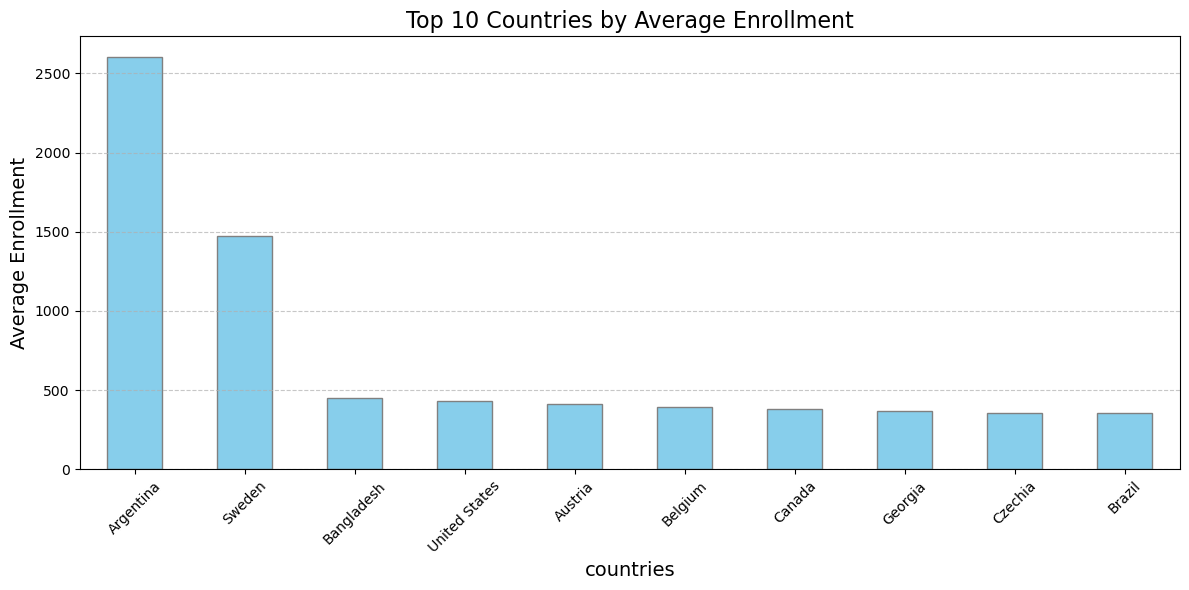

In [42]:
top_enrollment = df.groupby('countries')['Enrollment'].mean().sort_values(ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
top_enrollment.plot(kind='bar', color='skyblue', edgecolor='grey')
plt.title('Top 10 Countries by Average Enrollment', fontsize=16)
plt.xlabel('countries', fontsize=14)
plt.ylabel('Average Enrollment', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Top Conditions Observed

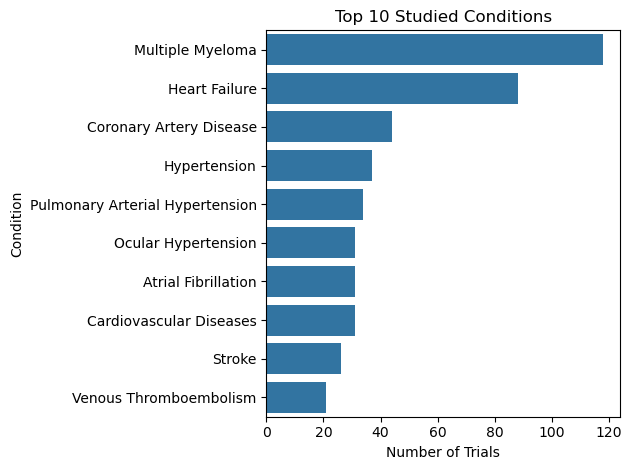

In [43]:
condition_series = df['Conditions'].dropna().str.split('|')

# Flatten the list of lists using pandas explode
flattened_conditions = condition_series.explode()

# Count top 10 most frequent conditions
top_conditions = flattened_conditions.value_counts().head(10).reset_index()
top_conditions.columns = ['Condition', 'Count']

# Plot using seaborn
sns.barplot(data=top_conditions, x='Count', y='Condition')
plt.title("Top 10 Studied Conditions")
plt.xlabel("Number of Trials")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()

 # Time-Based Analysis

C:\Users\shash\AppData\Local\Temp\ipykernel_11464\2970061621.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')


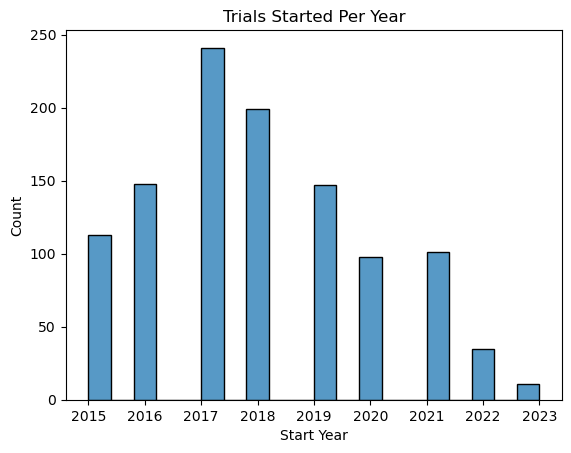

In [44]:
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Completion Date'] = pd.to_datetime(df['Completion Date'], errors='coerce')

df['Start Year'] = df['Start Date'].dt.year
sns.histplot(df['Start Year'].dropna(), bins=20, kde=False)
plt.title("Trials Started Per Year")
plt.show()


# Total Trials by Country

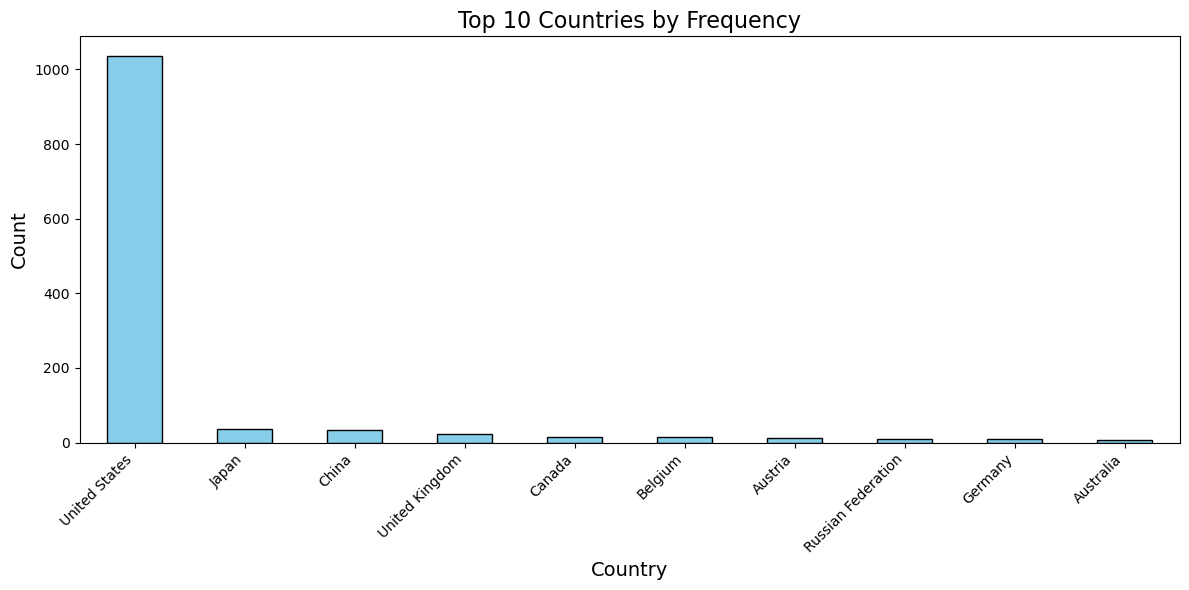

In [51]:
top_10_countries = df['countries'].value_counts().head(10)
plt.figure(figsize=(12, 6))

top_10_countries.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Top 10 Countries by Frequency", fontsize=16)
plt.xlabel("Country", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


In [49]:
df.groupby(['countries', 'Study Status']).size().unstack().fillna(0)


Study Status,COMPLETED,TERMINATED
countries,,
Argentina,6.0,0.0
Australia,7.0,1.0
Austria,11.0,0.0
Bangladesh,1.0,0.0
Belarus,1.0,1.0
Belgium,13.0,1.0
Brazil,2.0,0.0
Bulgaria,2.0,1.0
Canada,11.0,5.0


# Average Completion Time by Countries

In [ ]:
# Step 1: Convert start and completion dates to datetime
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Completion Date'] = pd.to_datetime(df['Completion Date'], errors='coerce')

# Step 2: Calculate completion time in years
df['Duration (Years)'] = (df['Completion Date'] - df['Start Date']).dt.total_seconds() / (365.25 * 24 * 3600)

# Step 3: Filter out rows with missing or negative durations
df_valid = df[(df['Duration (Years)'].notna()) & (df['Duration (Years)'] >= 0)]

# Step 4: Compute average duration by country
avg_duration_by_country = df_valid.groupby('countries')['Duration (Years)'].mean().sort_values(ascending=False).head(10)

# Step 5: Plot
plt.figure(figsize=(12, 6))
avg_duration_by_country.plot(kind='bar', color='lavender', edgecolor='grey')
plt.title('Top 10 Countries by Average Trial Completion Time (Years)', fontsize=16)
plt.xlabel('countries', fontsize=14)
plt.ylabel('Average Duration (Years)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Conclusion From Clinical Trial Study Analysis of Cardiovascular Diseases
1. The United States dominates the global clinical trial landscape, with the highest number of trials conducted.

2. Average enrollment varies by country, with some countries exhibiting significantly larger sample sizes—potentially reflecting larger healthcare infrastructure or regulatory flexibility.

3. Trial activity has decreases over time, with a clear decraese in the number of studies initiated per year, indicating lowering global interest in clinical trials for cardiovascular diseases as multiple effective treatments are availble maybe.

4. Completion times differ significantly by country, suggesting variability in trial complexity, regulatory timelines, recruitment efficiency, or operational capacity. Some countries exhibit longer average durations, which may reflect more complex studies.

Data inconsistencies and missing values in dates or locations emphasize the importance of better structured and standardized clinical trial reporting.consistancy is required in data collection.